## 1. Imports

In [460]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
# import pymc as pm
# import pytensor
# import pytensor.tensor as pt

# from pytensor.graph import Apply, Op

from numba import njit, prange

from scipy import optimize

from scipy.special import iv

import time

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.26.1


## 2. Log likelihood of a timeseries using bridges + simulation function defs

In [461]:
@njit
def random_numbers_for_bridges(NB, cols, seed_value):
    np.random.seed(seed_value)
    return np.random.random(size=(NB, cols))

def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]

def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]

def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    return sim_data

@njit
def BDM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result   

@njit
def SLM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result

@njit
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D, seed_value): 
    
    random_numbers = random_numbers_for_bridges(NB=NB, cols=bridge_steps-2, seed_value=seed_value)
    
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = random_numbers[:, step - 1] * np.sqrt(var_b) + mean_b    
    return B

@njit
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    # B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

@njit
def Gaussian_PDF(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

@njit
def log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return (( 2 * k * mu * np.log(x_f/x_i) - 
              np.log(x_f/x_i) * 0.5 - 
              k * (x_f**2 - x_i**2) * 0.25 )/
            (D**2)) - (Ihat / ( 2 * (D**2) ) )

@njit
def log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return (((k * mu - 0.5)*(x_f - x_i) - 
             k*(np.exp(x_f) - np.exp(x_i))
            ) / 
            (D**2)) - (Ihat / (2 * (D**2)))

@njit
def log_RN_Derivative(B, k, mu, D, Delta_t_B, eff_dt, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt)
    elif model == 'SLM':
        return log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt)

@njit(parallel=True)
def logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model='BDM'):

    # Pre-allocate the result array with the correct size
    n_bridges = len(bridges)
    logRND_array = np.empty(n_bridges)  # Pre-allocate
    
    # #Array of L_t for each bridge
    # logRND_array = np.array([])

    #For each bridge, calculate L and append to array
    for i in prange(n_bridges):
        bridge = bridges[i]
        logRND_array[i] = log_RN_Derivative(bridge, k, mu, D, Delta_t_B, eff_dt, model)

    return logRND_array

@njit
def est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model='BDM'):
    logRND_array = logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model)
    lL_star = np.max(logRND_array)
    G = Gaussian_PDF(x_f, x_i, eff_dt)
    return lL_star + np.log(G) - np.log(NB) + np.log(np.sum(np.exp(logRND_array - lL_star)))

@njit(parallel=True)
def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model='BDM'):

    # Pre-allocate result array
    n_pairs = len(data) - 1
    log_rho_array = np.empty(n_pairs)  # Pre-allocate with correct size

    for i in prange(n_pairs):
        x_i = data[i]
        x_f = data[i + 1]
        seed_value = seed_array[i]
        
        bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D, seed_value)
        log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
        # log_rho_array = np.append(log_rho_array, log_propagator)
        log_rho_array[i] = log_propagator

    return log_rho_array

@njit
def log_propagators_target_process(log_rho_array, data, model='BDM'):
    valid_models = {"BDM", "SLM"}

    data = data[1:]

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        h_prime = 1 / np.sqrt(data)
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array
    elif model == 'SLM':
        h_prime = 1 / data
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array

@njit
def ts_logL(log_rho_array, p0):
    return np.sum(log_rho_array) + np.log(p0)
    
def full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code=0):
    
    models = ['BDM', 'SLM']
    model = models[model_code]

    if model == 'BDM':
        lamperti_tf_data = BDM_Lamperti(sim_data)   
    elif model == 'SLM':
        lamperti_tf_data = SLM_Lamperti(sim_data)

    log_rho_tilde_array = log_propagators_transformed_data(
        lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model
    )
    
    timeseries_logL = ts_logL(log_propagators_target_process(log_rho_tilde_array, sim_data, model), 1.0)
    
    return timeseries_logL

### 2.1. Compiling Numba

Numba compiles the decorated functions the first time it is called. We do this here, before any significant code is run.

In [462]:
# Parameters

MODEL = 'BDM'
model_code = 0

X0 = 155
k = 1
mu = 155
dt = 3e-3 #timestep of the simulation
T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
real_sigma = 0.54 #real sigma such that D = sqrt(sigma / tau) = sqrt (k * sigma)
D = np.sqrt(real_sigma * k)
N = round(T+1 / eff_dt) #number of datapoints
timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt
bridge_steps = int(timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 
datapoint_times = np.linspace(0, T, N)

seed=333
seed_array=np.random.default_rng(seed=seed).integers(1, 5000, size=N-1)

In [463]:
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))

In [464]:
print(len(sim_data)-1)

100


In [465]:
print(len(seed_array))

100


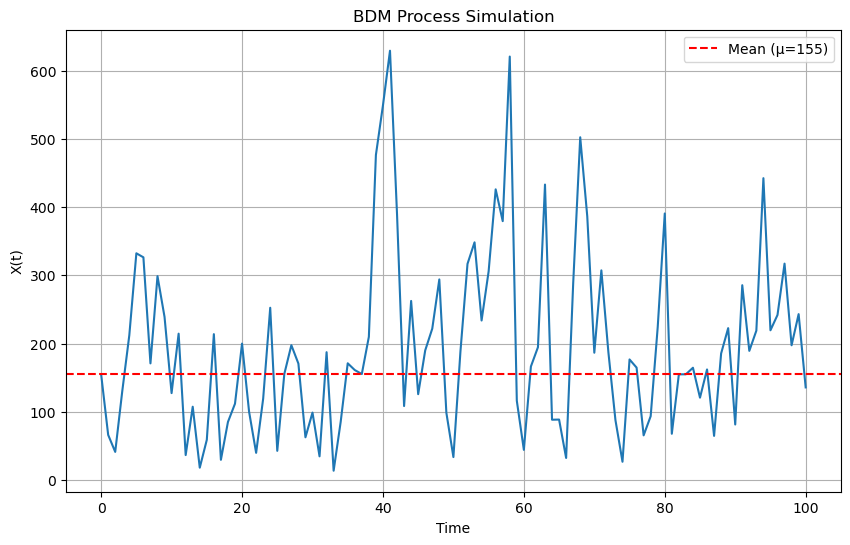

In [466]:
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [467]:
loglogl = full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code)
print(loglogl)

-12419.546010980004


## MLE of $\mu$ via optimization of estimated loglikelihood

In [469]:
def neg_loglike(mu_scalar):
    # mu_scalar comes in as a 1-D float from the optimiser
    return -full_logL_pipeline(
        sim_data, NB, bridge_steps, Delta_t_B, D, k, float(mu_scalar),
        seed_array, model_code
    )
    
starttime = time.time()

result = optimize.minimize_scalar(
    neg_loglike,
    bounds=(150.0, 160.0),      # <-- put sensible bounds for μ
    method='bounded',
    options={'xatol': 1e-3}  # convergence tolerance
)

mle_mu  = result.x
max_logL = -result.fun
print(f"MLE(mu) ≃ {mle_mu:.4f},   log-L = {max_logL:.3f}")

endtime = time.time()

print(f"Total runtime of the program is {endtime - starttime} seconds")

MLE(mu) ≃ 159.6115,   log-L = -12407.341
Total runtime of the program is 1.5161590576171875 seconds


In [470]:
print(np.mean(sim_data))

195.56519130911127


## Exact MLE for the BDM

In [471]:
def exactLogLikelihoodBDM_transition(x_i, x_f, dt, mu, k, D):

    t = dt
    
    term1 = (k*mu / D**2) * np.log(k / D**2) + (k * mu / D**2 - 1) * np.log(x_f) - x_f*k/D**2
    term2 = (0.5 - k * mu / (2*D**2)) * np.log( (k / D**2) ** 2 * x_i * x_f * np.exp(-k * t) ) - np.log(1 - np.exp(-k*t))
    term3 = - ( k/D**2 * (x_f+x_i) * np.exp(- k * t) ) / (1 - np.exp(-k * t))
    bessel_fc_arg = ( 2 * k / D**2 * np.sqrt(x_i * x_f * np.exp (- k * t)) ) / (1 - np.exp(- k * t))
    term4 = np.log(iv( (k * mu / D**2 - 1) , bessel_fc_arg ) )

    return term1 + term2 + term3 + term4

def exactLogLikelihoodBDM_timeseries(data, mu, k, D, dt):
    
    n_pairs = len(data) - 1
    log_rho_array = np.empty(n_pairs)

    for i in range(n_pairs):
        x_i = data[i]
        x_f = data[i + 1]
        log_rho_array[i] = exactLogLikelihoodBDM_transition(x_i, x_f, dt, mu, k, D)

    return np.sum(log_rho_array)

In [472]:
x_i = sim_data[3]
x_f = sim_data[4]
t = eff_dt

In [473]:
print((k*mu / D**2) * np.log(k / D**2) + (k * mu / D**2 - 1) * np.log(x_f) - x_f*k/D**2)

1316.3395701815841


In [474]:
print((0.5 - k * mu / (2*D**2)) * np.log( (k / D**2) ** 2 * x_i * x_f * np.exp(-k * t) ) - np.log(1 - np.exp(-k*t)))

-1495.4323017812956


In [475]:
print(- ( k/D**2 * (x_f+x_i) * np.exp(- k * t) ) / (1 - np.exp(-k * t)))

-369.0937169109958


In [476]:
print( ( 2 * k / D**2 * np.sqrt(x_i * x_f * np.exp (- k * t)) ) / (1 - np.exp(- k * t)) )

590.8328247426748


In [477]:
bessel_fc_arg = ( 2 * k / D**2 * np.sqrt(x_i * x_f * np.exp (- k * t)) ) / (1 - np.exp(- k * t))

In [478]:
print(bessel_fc_arg)

590.8328247426748


In [479]:
print(iv( (k * mu / D**2 - 1) , bessel_fc_arg ))

1.851847514873335e+225


In [480]:
print(np.log(iv( (k * mu / D**2 - 1) , bessel_fc_arg ) ))

518.697829721113


In [481]:
print(exactLogLikelihoodBDM_timeseries(sim_data, mu, k, D, eff_dt))

inf


In [483]:
print( np.power((k / D**2),(k*mu / D**2)))

6.499834115967182e+76


## 5. True Parameters

## 6. Timeseries simulation

## 7. Parameter Inference